### Imports

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sys.path.append(os.path.abspath(".."))
from extract import load_dataframes

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as spark_sum
from pyspark.ml.feature import StringIndexer, OneHotEncoder

### Data loading

In [2]:
spark = SparkSession.builder.appName("Analysis").getOrCreate()

dfs = load_dataframes(spark, "/app/Data")

df_demo = dfs["demographics"]
df_acc = dfs["accidents"]
df_net  = dfs["internet"]

Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/29 08:59:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Data read:

Demographics (PUSA + PUSB):


+---+-------------+--------+-------+----+------+---+-------+-----+----+
| RT|     SERIALNO|DIVISION|SPORDER|PUMA|REGION| ST| ADJINC|PWGTP|AGEP|
+---+-------------+--------+-------+----+------+---+-------+-----+----+
|  P|2022GQ0000031|       6|      1|2803|     3| 01|1042311|   69|  85|
|  P|2022GQ0000111|       6|      1|2000|     3| 01|1042311|   22|  51|
|  P|2022GQ0000200|       6|      1|2803|     3| 01|1042311|   45|  36|
|  P|2022GQ0000261|       6|      1|1100|     3| 01|1042311|    4|  74|
|  P|2022GQ0000296|       6|      1|1502|     3| 01|1042311|   47|  49|
+---+-------------+--------+-------+----+------+---+-------+-----+----+
only showing top 5 rows

Accidents:
+---+-------+--------+-------------------+-------------------+---------+----------+-------+-------+------------+
| ID| Source|Severity|         Start_Time|           End_Time|Start_Lat| Start_Lng|End_Lat|End_Lng|Distance(mi)|
+---+-------+--------+-------------------+-------------------+---------+----------+-------

### All columns in accident dataset

In [3]:
df_acc.columns

['ID',
 'Source',
 'Severity',
 'Start_Time',
 'End_Time',
 'Start_Lat',
 'Start_Lng',
 'End_Lat',
 'End_Lng',
 'Distance(mi)',
 'Description',
 'Street',
 'City',
 'County',
 'State',
 'Zipcode',
 'Country',
 'Timezone',
 'Airport_Code',
 'Weather_Timestamp',
 'Temperature(F)',
 'Wind_Chill(F)',
 'Humidity(%)',
 'Pressure(in)',
 'Visibility(mi)',
 'Wind_Direction',
 'Wind_Speed(mph)',
 'Precipitation(in)',
 'Weather_Condition',
 'Amenity',
 'Bump',
 'Crossing',
 'Give_Way',
 'Junction',
 'No_Exit',
 'Railway',
 'Roundabout',
 'Station',
 'Stop',
 'Traffic_Calming',
 'Traffic_Signal',
 'Turning_Loop',
 'Sunrise_Sunset',
 'Civil_Twilight',
 'Nautical_Twilight',
 'Astronomical_Twilight']

### Unique values in target field(accidents dataset)

In [4]:
df_acc.select("Severity").distinct().show()

+--------+
|Severity|
+--------+
|       1|
|       3|
|       4|
|       2|
+--------+



### Null check

25/11/23 12:34:25 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
/tmp/ipykernel_11747/772354974.py:13: FutureWarning:                            

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_counts_df.index, y='percent_nulls', data=null_counts_df, palette='magma')


=== Number of missing values in columns ===
End_Lng: 3402762
End_Lat: 3402762
Precipitation(in): 2203586
Wind_Chill(F): 1999019
Wind_Speed(mph): 571233
Visibility(mi): 177098
Wind_Direction: 175206
Humidity(%): 174144
Weather_Condition: 173459
Temperature(F): 163853
Pressure(in): 140679
Weather_Timestamp: 120228
Sunrise_Sunset: 23246
Civil_Twilight: 23246
Astronomical_Twilight: 23246
Nautical_Twilight: 23246
Airport_Code: 22635
Street: 10869
Timezone: 7808
Zipcode: 1915
City: 253
Description: 5
ID: 0
Distance(mi): 0
Start_Lng: 0
Source: 0
Severity: 0
Start_Time: 0
End_Time: 0
Start_Lat: 0
County: 0
Amenity: 0
Country: 0
State: 0
Bump: 0
Crossing: 0
Give_Way: 0
Junction: 0
Station: 0
Roundabout: 0
Railway: 0
No_Exit: 0
Turning_Loop: 0
Traffic_Signal: 0
Traffic_Calming: 0
Stop: 0


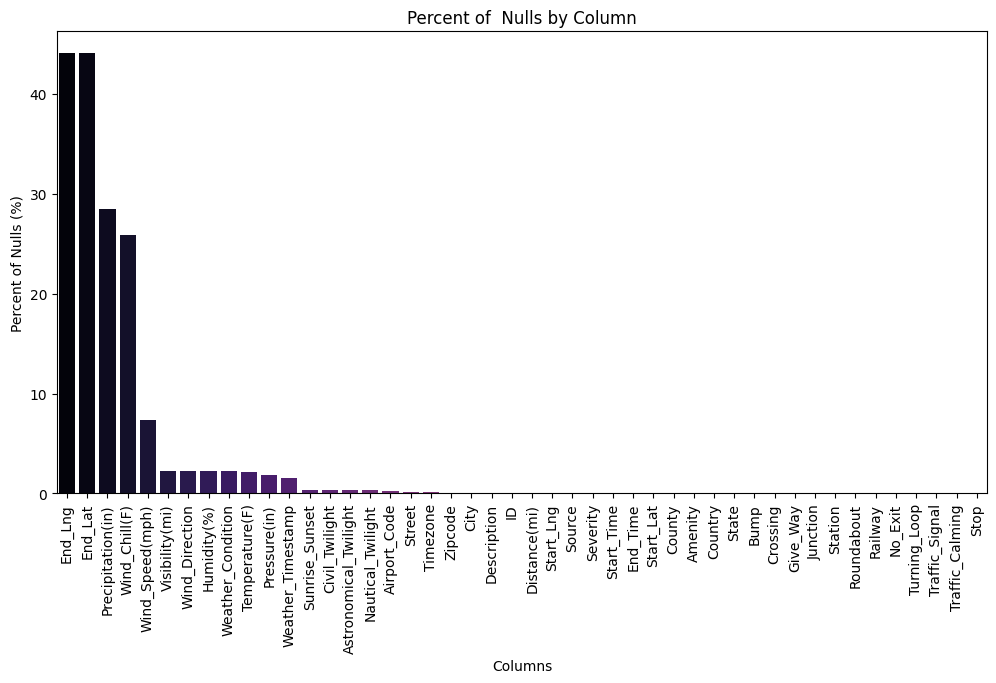

In [5]:
total_rows = df_acc.count()

null_counts = df_acc.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in df_acc.columns])
null_counts_df = null_counts.toPandas().T.rename(columns={0: 'num_nulls'}).sort_values('num_nulls', ascending=False)

print("=== Number of missing values in columns ===")
for col_name, row in null_counts_df.iterrows():
    print(f"{col_name}: {row['num_nulls']}")

null_counts_df['percent_nulls'] = null_counts_df['num_nulls'] / total_rows * 100

plt.figure(figsize=(12,6))
sns.barplot(x=null_counts_df.index, y='percent_nulls', data=null_counts_df, palette='magma')
plt.xticks(rotation=90)
plt.ylabel("Percent of Nulls (%)")
plt.xlabel("Columns")
plt.title("Percent of  Nulls by Column")
plt.show()

Conclusions: 
- fields 'End_Lng' and 'End_Lat' we can omit since there is no point to include them int the forecast because we don't know in advance how much the car will move after the accident
- for fields 'Precipitation(in)', 'Wind_Chill(F)' and 'Wind_Speed(mph)' it makes sense to replace nulls with values
- for other fields the number of nulls is not significant compared to the sample, so we can remove rows with nulls

### Distributions for numeric cols

10 percent of the total sample was taken for visualization. This will allow us to understand the general distribution of data and not overload the device's memory

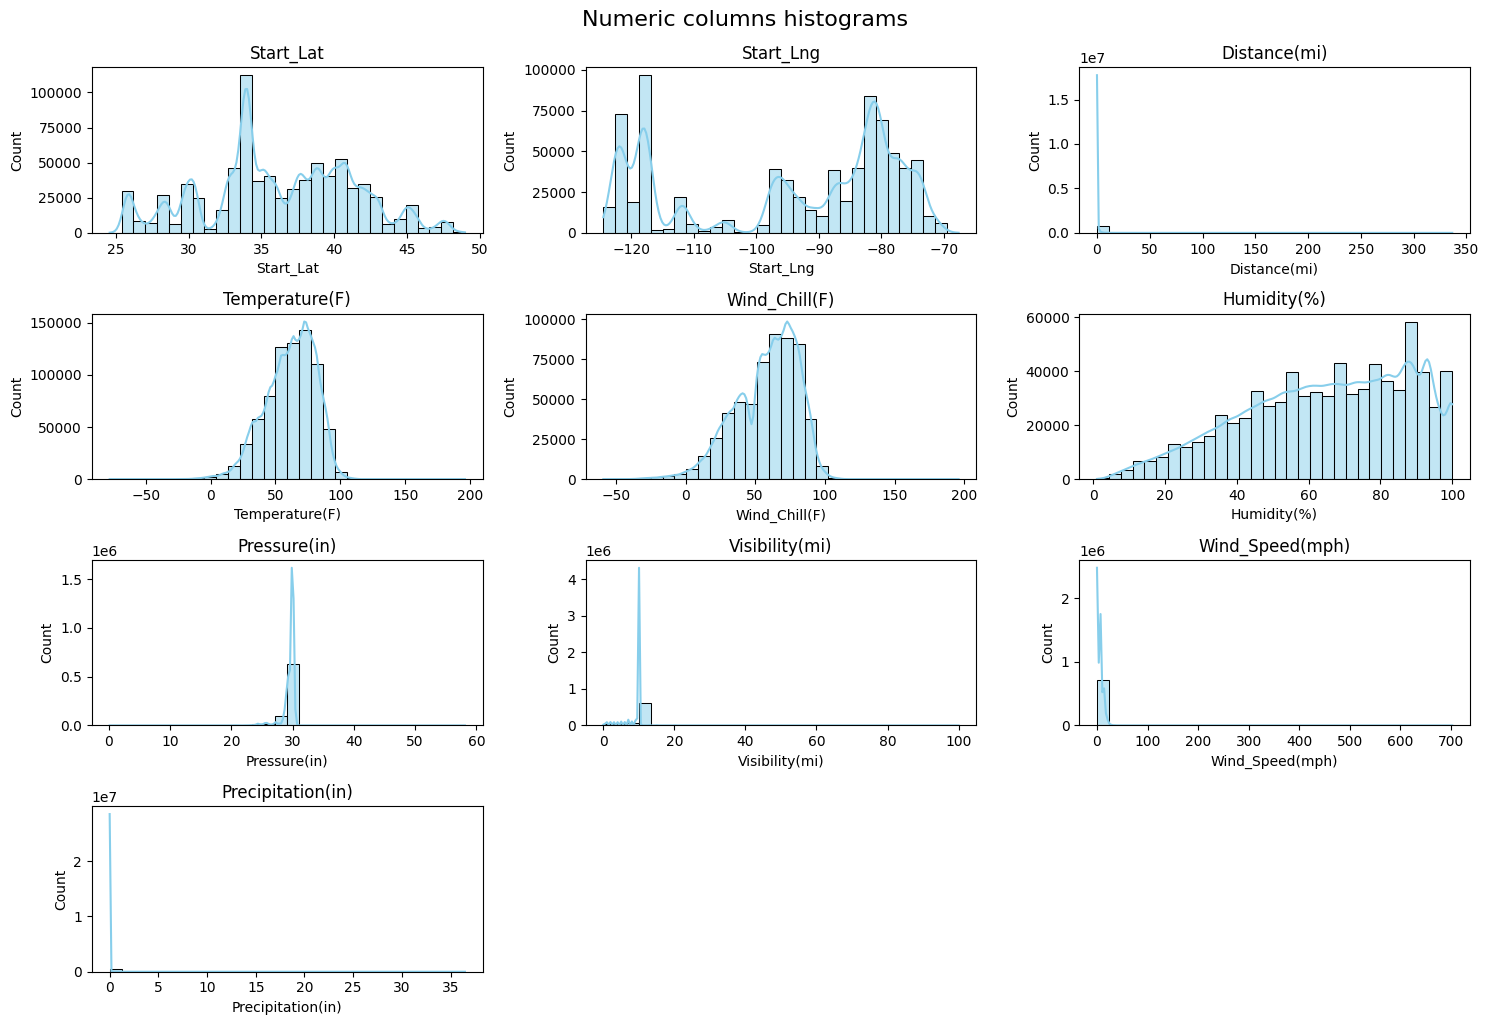

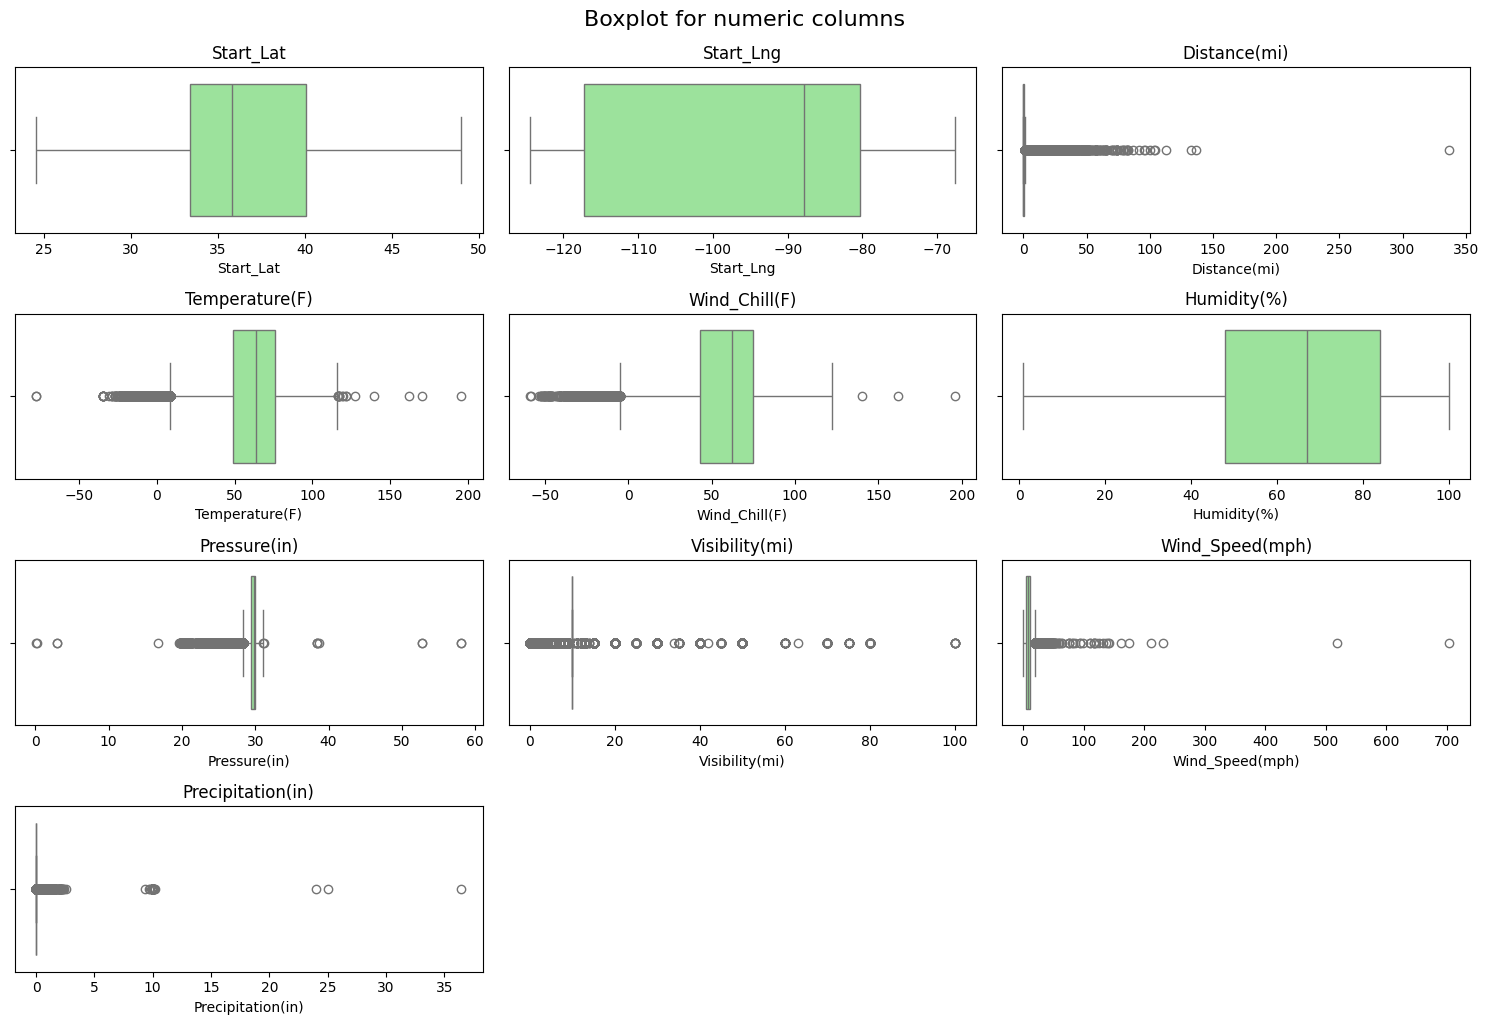

In [6]:
numeric_cols = ['Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)',
                'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
                'Wind_Speed(mph)', 'Precipitation(in)']

numeric_sample_df = df_acc.select(numeric_cols).sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(15, 10))
for i, col_name in enumerate(numeric_cols):
    plt.subplot(4, 3, i+1)
    sns.histplot(numeric_sample_df[col_name].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(col_name)
plt.tight_layout()
plt.suptitle("Numeric columns histograms", y=1.02, fontsize=16)
plt.show()

plt.figure(figsize=(15, 10))
for i, col_name in enumerate(numeric_cols):
    plt.subplot(4, 3, i+1)
    sns.boxplot(x=numeric_sample_df[col_name], color='lightgreen')
    plt.title(col_name)
plt.tight_layout()
plt.suptitle("Boxplot for numeric columns", y=1.02, fontsize=16)
plt.show()

Conclusions: 
- fields such us 'Distance(mi)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)' should be further processed due to outliers

### Correlation analysis

In [7]:
spark = SparkSession.builder \
    .appName("Severity Analysis") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .getOrCreate()

dfs = load_dataframes(spark, "/app/Data")
df_acc = dfs["accidents"]

high_card_cols = ['ID', 'Source', 'Start_Time', 'End_Time', 'End_Lat', 'End_Lng', 
                  'Description', 'Street', 'City', 'Zipcode', 'Country',
                  'Weather_Timestamp', 'Airport_Code', 'Turning_Loop']
df_acc = df_acc.drop(*high_card_cols)

numeric_cols = ['Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)',
                'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
                'Wind_Speed(mph)', 'Precipitation(in)']

categorical_cols = [c for c in df_acc.columns if c not in numeric_cols + ['Severity']]

bool_cols = [c for c in categorical_cols if str(df_acc.schema[c].dataType) == "BooleanType"]
for c in bool_cols:
    df_acc = df_acc.withColumn(c+"_num", col(c).cast("int"))

categorical_cols = [c for c in categorical_cols if str(df_acc.schema[c].dataType) != "BooleanType"]

print("=== Pearson correlations ===")
for c in numeric_cols + [c+"_num" for c in bool_cols]:
    corr = df_acc.stat.corr(c, "Severity")
    print(f"{c}: {corr:.3f}")

indexed_cols = []
for c in categorical_cols:
    indexer = StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="skip")
    df_acc = indexer.fit(df_acc).transform(df_acc)
    indexed_cols.append(c+"_idx")

encoder = OneHotEncoder(inputCols=indexed_cols, outputCols=[c+"_ohe" for c in indexed_cols])
df_acc = encoder.fit(df_acc).transform(df_acc)

def cramers_v(df, col1, col2, sample_frac=0.1):
    """
    Calculates Cramér's V for two categorical columns.
    Uses sampling for large datasets.
    """
    df_sample = df.sample(fraction=sample_frac, seed=42).toPandas()
    table = pd.crosstab(df_sample[col1], df_sample[col2])
    chi2, _, _, _ = chi2_contingency(table)
    n = table.sum().sum()
    k = min(table.shape)-1
    return (chi2 / (n*k))**0.5

print("=== Cramér's V ===")
for c in categorical_cols:
    try:
        v = cramers_v(df_acc, c, "Severity", sample_frac=0.05)  # small sample for performance
        print(f"{c}: {v:.3f}")
    except Exception as e:
        print(f"{c}: error {e}")

Data read:

Demographics (PUSA + PUSB):
+---+-------------+--------+-------+----+------+---+-------+-----+----+
| RT|     SERIALNO|DIVISION|SPORDER|PUMA|REGION| ST| ADJINC|PWGTP|AGEP|
+---+-------------+--------+-------+----+------+---+-------+-----+----+
|  P|2022GQ0000031|       6|      1|2803|     3| 01|1042311|   69|  85|
|  P|2022GQ0000111|       6|      1|2000|     3| 01|1042311|   22|  51|
|  P|2022GQ0000200|       6|      1|2803|     3| 01|1042311|   45|  36|
|  P|2022GQ0000261|       6|      1|1100|     3| 01|1042311|    4|  74|
|  P|2022GQ0000296|       6|      1|1502|     3| 01|1042311|   47|  49|
+---+-------------+--------+-------+----+------+---+-------+-----+----+
only showing top 5 rows

Accidents:
+---+-------+--------+-------------------+-------------------+---------+----------+-------+-------+------------+
| ID| Source|Severity|         Start_Time|           End_Time|Start_Lat| Start_Lng|End_Lat|End_Lng|Distance(mi)|
+---+-------+--------+-------------------+--------

Start_Lat: 0.069


Start_Lng: 0.053


Distance(mi): 0.035


Temperature(F): -0.021


...

Weather_Condition: 0.129


Sunrise_Sunset: 0.049


Civil_Twilight: 0.054


Nautical_Twilight: 0.059


Astronomical_Twilight: 0.062


You might have noticed that there is a list `high_card_cols` which tells which fields not to include for analysis, the reason why some columns are excluded - some of them are not meaningful for forecasting such as 'End_Lat' and 'End_Lgt' we can't have this data before the crush, 'Turning_Loop' is always false so it's not meaningful to use, and others have a lot of unique values which are hard to code

### Visualization of correlation

/tmp/ipykernel_11747/4129231245.py:25: FutureWarning:                           

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation', y=cramers_df.index, data=cramers_df, palette='viridis', ax=axes[1])


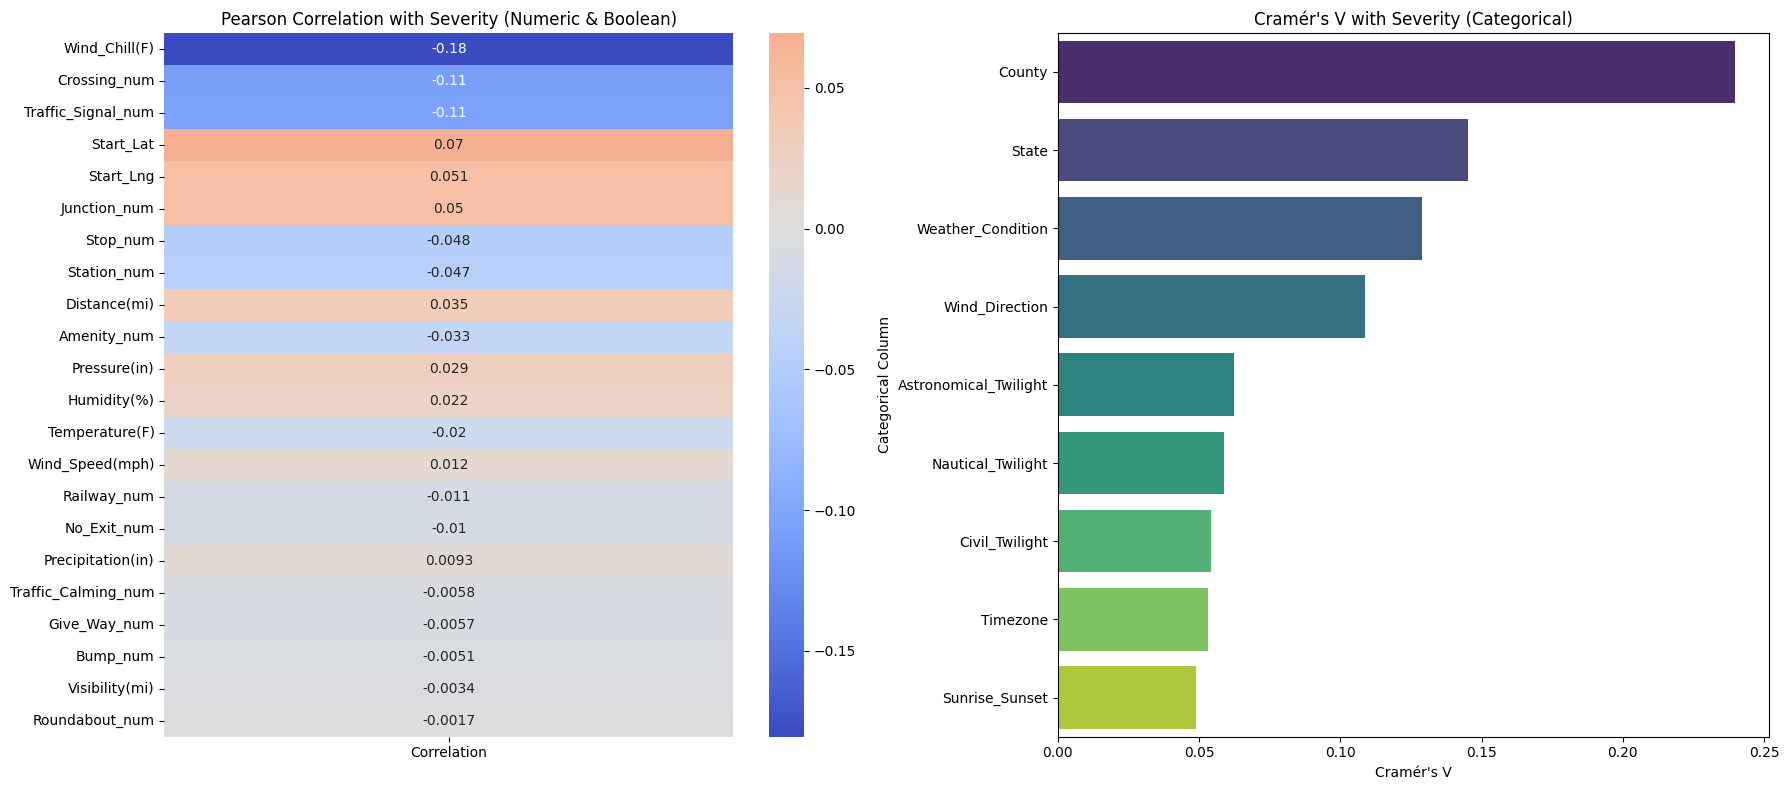

In [8]:
pearson_dict = {}
for c in numeric_cols + [c+"_num" for c in bool_cols]:
    corr = df_acc.stat.corr(c, "Severity")
    pearson_dict[c] = corr

pearson_df = pd.DataFrame.from_dict(pearson_dict, orient='index', columns=['Correlation'])
pearson_df = pearson_df.sort_values('Correlation', key=abs, ascending=False)

cramers_dict = {}
for c in categorical_cols:
    try:
        v = cramers_v(df_acc, c, "Severity", sample_frac=0.05)
        cramers_dict[c] = v
    except:
        cramers_dict[c] = None

cramers_df = pd.DataFrame.from_dict(cramers_dict, orient='index', columns=['Correlation'])
cramers_df = cramers_df.sort_values('Correlation', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(pearson_df, annot=True, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title("Pearson Correlation with Severity (Numeric & Boolean)")

sns.barplot(x='Correlation', y=cramers_df.index, data=cramers_df, palette='viridis', ax=axes[1])
axes[1].set_title("Cramér's V with Severity (Categorical)")
axes[1].set_xlabel("Cramér's V")
axes[1].set_ylabel("Categorical Column")

plt.tight_layout()
plt.show()